In [1]:
import warnings

warnings.filterwarnings('ignore')
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse

import matplotlib.pyplot as plt
import os
import torch
from utils.graph_construction import cal_spatial_network
from scipy.sparse import bmat
from graph import AlignDG

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
sc.set_figure_params(figsize=(4, 4))
os.environ['R_HOME'] = 'C:/Program Files/R/R-4.3.1'

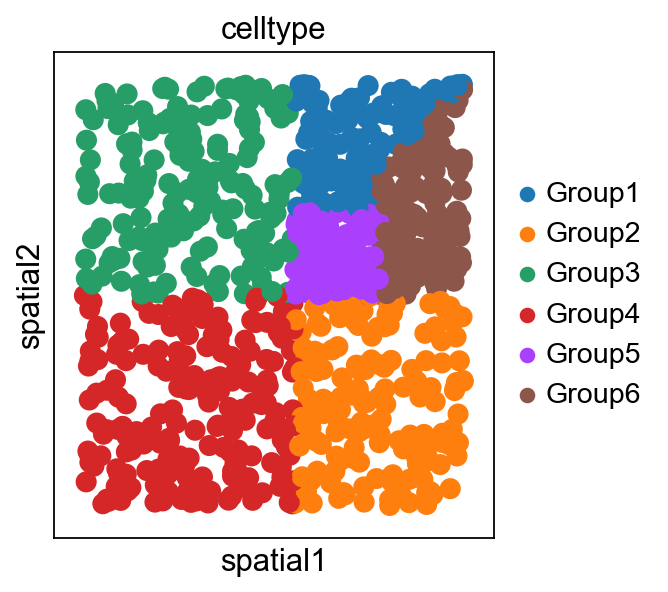

In [3]:
adata = sc.read_h5ad('../data/simulate1.h5ad')
sc.pl.spatial(adata, color=['celltype'], spot_size=0.5)
adata_sub1 = adata[adata.obs['batch'] == 'Batch1']
adata_sub2 = adata[adata.obs['batch'] == 'Batch2']

In [4]:
adata1_harm_df = pd.DataFrame({
    'index': range(adata_sub1.shape[0]),
    'x': adata_sub1.obsm['spatial'][:, 0],
    'y': adata_sub1.obsm['spatial'][:, 1],
    'domain': adata_sub1.obs['celltype'].astype('category'),
})

adata2_harm_df = pd.DataFrame({
    'index': range(adata_sub2.shape[0]),
    'x': adata_sub2.obsm['spatial'][:, 0],
    'y': adata_sub2.obsm['spatial'][:, 1],
    'domain': adata_sub2.obs['celltype'].astype('category'),
})

adata1_harm_df, adata2_harm_df

(         index         x         y  domain
 Cell1        0  1.037015  0.727646  Group3
 Cell2        1  7.301914  9.436571  Group2
 Cell3        2  5.493741  5.021805  Group2
 Cell4        3  6.041019  9.825238  Group2
 Cell5        4  6.947731  4.347541  Group5
 ...        ...       ...       ...     ...
 Cell496    495  0.048206  9.434689  Group4
 Cell497    496  7.969817  7.419835  Group2
 Cell498    497  3.112033  2.076640  Group3
 Cell499    498  7.234705  9.352265  Group2
 Cell500    499  5.126478  8.129682  Group2
 
 [500 rows x 4 columns],
           index         x         y  domain
 Cell501       0  7.181161  5.700499  Group2
 Cell502       1  7.951904  0.702857  Group1
 Cell503       2  5.376372  0.877961  Group1
 Cell504       3  0.054656  1.326532  Group3
 Cell505       4  6.388294  8.878522  Group2
 ...         ...       ...       ...     ...
 Cell996     495  0.426510  4.551456  Group3
 Cell997     496  6.570264  2.578510  Group1
 Cell998     497  3.063378  5.954876  Gr

In [5]:
adj_list = []
section_ids = ['Batch1', 'Batch2']
adata_list = [adata_sub1, adata_sub2]
for i in range(len(adata_list)):
    adata_list[i].X = sparse.csc_matrix(adata_list[i].X)
    adata_list[i].var_names_make_unique(join="++")
    adata_list[i].obs_names = [x + '_' + section_ids[i] for x in adata_list[i].obs_names]
    cal_spatial_network(adata_list[i], model='KNN', k_cutoff=2)
    adj_list.append(adata_list[i].uns['adj'])

Calculating spatial neighbor graph ...
The graph contains 1214 edges, 500 cells
2.428 neighbors per cell on average
Calculating spatial neighbor graph ...
The graph contains 1210 edges, 500 cells
2.42 neighbors per cell on average


In [6]:
from scipy.sparse import block_diag

adata_concat = ad.concat(adata_list, label='slice_name', keys=section_ids)
adj_concat = block_diag(adj_list)
adata_concat.uns['edge_list'] = np.nonzero(adj_concat)
adata_concat

AnnData object with n_obs × n_vars = 1000 × 500
    obs: 'celltype', 'batch', 'slice_name', 'batch_name'
    uns: 'edge_list'
    obsm: 'spatial'

In [7]:
adata_concat, pis = AlignDG.train_AlignDG(adata=adata_concat, beta=0.5, iter_comb=[(0, 1)])
print(adata_concat)

  0%|          | 0/500 [00:00<?, ?it/s]

Update spot triplet at epoch 500
Processing datasets ('Batch1', 'Batch2')
Solver may not converge.


# Epoch 599, loss: 0.244, gene_recon: 0.241, triplet loss: 0.0032623102888464928:  17%|█▋        | 86/500 [00:15<00:20, 19.79it/s]

Update spot triplet at epoch 600
Processing datasets ('Batch1', 'Batch2')


# Epoch 634, loss: 0.355, gene_recon: 0.319, triplet loss: 0.03581279143691063:  25%|██▌       | 126/500 [00:30<01:09,  5.38it/s] 

...

Update spot triplet at epoch 900
Processing datasets ('Batch1', 'Batch2')


# Epoch 906, loss: 0.406, gene_recon: 0.261, triplet loss: 0.14458712935447693:  78%|███████▊  | 389/500 [01:18<00:06, 18.03it/s] 

Solver may not converge.


# Epoch 999, loss: 0.198, gene_recon: 0.186, triplet loss: 0.012565851211547852: 100%|██████████| 500/500 [01:19<00:00,  6.33it/s]

AnnData object with n_obs × n_vars = 1000 × 500
    obs: 'celltype', 'batch', 'slice_name', 'batch_name'
    uns: 'edge_list'
    obsm: 'spatial', 'raw_latent', 'latent'


In [8]:
mapping_pi = pis[0]
count = 0
ref_raw_list = []
index = []
for i in range(mapping_pi.shape[0]):
    if np.sum(mapping_pi[i] > 0):
        index.append(i)
        source_domain = adata_sub1.obs['celltype'][i]
        max_align = mapping_pi[i].argsort()[-1]
        target_domain = adata_sub2.obs['celltype'].values[max_align]
        ref_raw_list.append(max_align)
        if source_domain == target_domain:
            count = count + 1

print(count / len(ref_raw_list), count, len(ref_raw_list))

index_harm = np.array(ref_raw_list)
matching_harm = np.array([index, index_harm])

0.978 489 500


In [9]:
def get_ratio_unbalanced(alignment, labels):
    matched_idx_list = []
    ad1_match_label = []
    ad2_match_label = [2] * alignment.shape[1]

    unique_labels_slice1 = set(labels[:alignment.shape[0]])
    unique_labels_slice2 = set(labels[alignment.shape[0]:])
    common_labels = unique_labels_slice1.intersection(unique_labels_slice2)

    indices_slice1 = [i for i in range(alignment.shape[0]) if labels[i] in common_labels]

    for i in indices_slice1:
        elem = alignment[i]
        max_idx = elem.argmax()
        matched_idx = max_idx + alignment.shape[0]

        if labels[i] == labels[matched_idx]:
            ad1_match_label.append(1)
            ad2_match_label[max_idx] = 1
            matched_idx_list.append(max_idx)
        else:
            ad1_match_label.append(0)
            ad2_match_label[max_idx] = 0
    return len(indices_slice1) / len(set(matched_idx_list))

In [10]:
get_ratio_unbalanced(alignment=np.array(mapping_pi), labels=adata_concat.obs['celltype'])

1.1013215859030836

dataset1: 6 cell types; dataset2: 6 cell types; 
                    Total :6 celltypes; Overlap: 6 cell types 
                    Not overlap :[[]]
Subsampled 150 pairs from 500


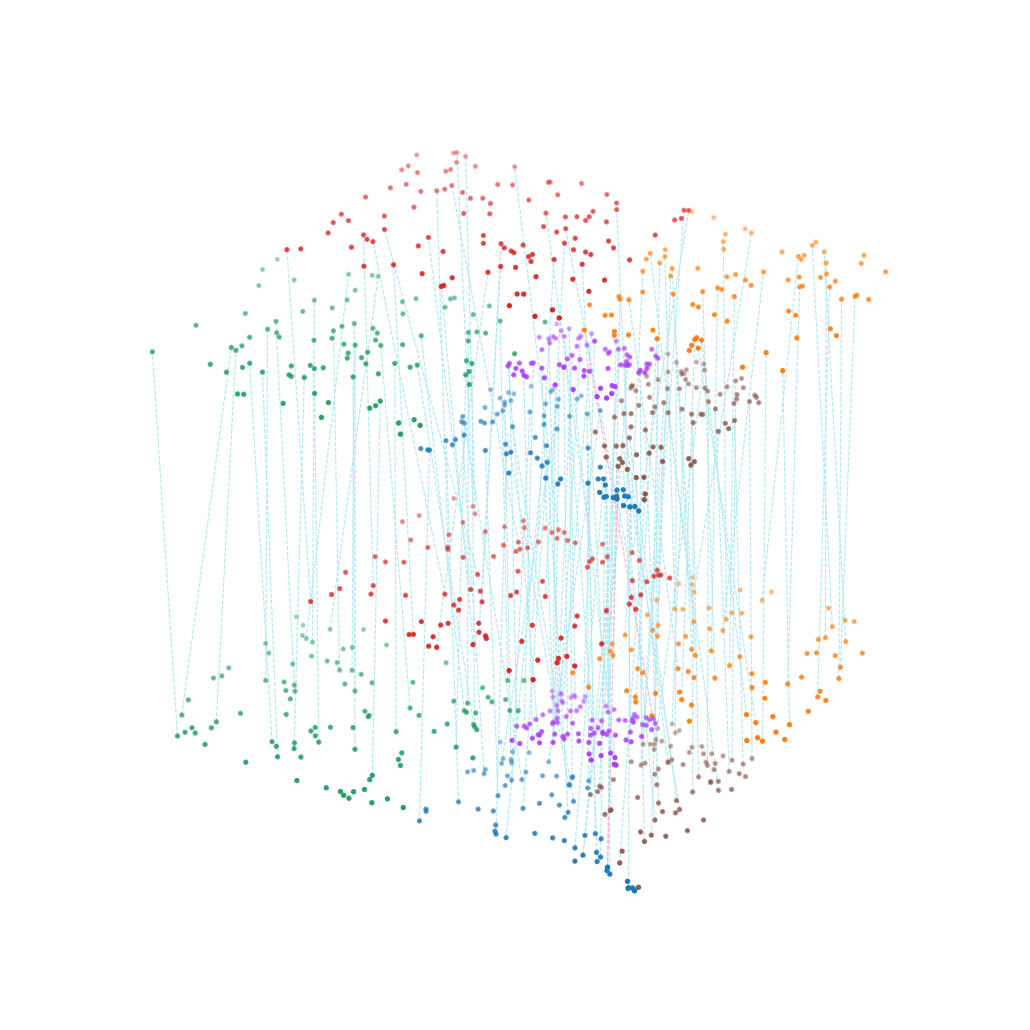

In [11]:
from utils.visualize import Build3D

multi_align = Build3D(adata2_harm_df, adata1_harm_df, matching_harm, meta='domain', scale_coordinate=True,subsample_size=150, exchange_xy=False)
multi_align.draw_3D(size=[8, 10], line_width=0.5, point_size=[2, 2], line_alpha=1, hide_axis=True, show_error=True)